### Import pysammos

In [1]:
import os
os.environ["NUMBA_NUM_THREADS"] = "8"
print(f">>> Numba is using {os.environ['NUMBA_NUM_THREADS']} cores")

>>> Numba is using 8 cores


In [2]:
import numpy as np

In [3]:
from pysammos.utils.config_loader import load_config
from pysammos.coarse_graining import CoarseGraining

Hello from pysammos
Loading macroscopic_fields package...
Loading data_read package...
Loading particle_phase package...
Loading spatial_weights package...
Loading neighbour_search package...
Loading grid_generation package...
Loading data_handle package...
Loading data_write package...


### Run Coarse - Graining Workflow

Initialise the Coarse Graining class

In [4]:
# Load the configuration from the ini file
cfg = load_config("config.ini")  
print("-------------------- config.ini file read --------------------")
# Initialize the CoarseGraining class with the loaded configuration
CG = CoarseGraining(
    particle_path=cfg["particles_path"],
    contacts_path=cfg["contacts_path"],
    output_path=cfg["output_path"],
    start_timestep=cfg["t0"],
    end_timestep=cfg["tf"],
    dt_time_step=cfg["dt"],
    DEM_keymap=cfg["key_mapping"],
    grid_info=cfg["grid_info"],
    weight_function=cfg["smoothing_function"],
    fields_to_export=cfg["fields_to_export"],
    ignore_phases=cfg["partialignore"],
    h5_output=cfg["h5_output"],
    vkthdf_output=cfg["vkthdf_output"],
                    ) 
print("  ") ; print("-------------------- CoarseGraining class initialised --------------------")

-------------------- config.ini file read --------------------
Output path created: ./PysammosCG/
  
-------------------- CoarseGraining class initialised --------------------


Option (A) Run all at once:

In [5]:
#CG.run()

Option (B) Run step by step:

In [6]:
# 1. Load the size-relevant particle data for the first time step
Bounds_t0, Diameter_t0, Density_t0, Mass_t0, GlobalID_t0 = CG.data_sampling()

XML-based PolyData detected.


In [7]:
# 2. Calculate the particle size range
CG.get_particle_size_statistics(Diameter_t0, Mass_t0)
print(">> Particle size statistics: ") 
print("       d43: ", CG.d43)
print("       dmax: ", CG.dmax)
print("       d50: ", CG.d50)
print("       d32: ", CG.d32)
print("       drms: ", CG.drms)

>> Particle size statistics: 
       d43:  0.005067612399400709
       dmax:  0.005999645
       d50:  0.005061278
       d32:  0.005012527178597786
       drms:  0.004928972383396669


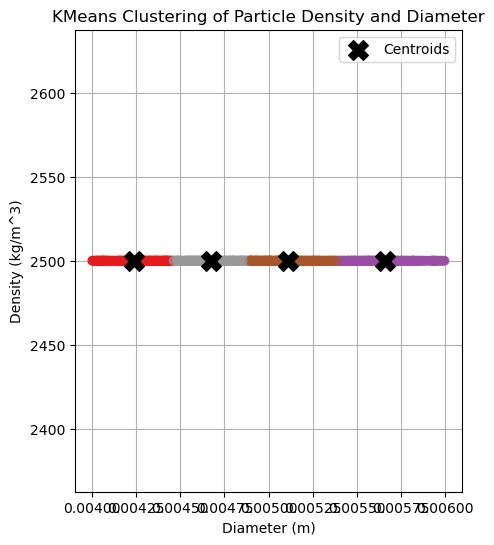

>> Phases: 
       Diameters:  [0.00423757 0.00566325 0.00510815 0.00467504]
       Densities:  [2500. 2500. 2500. 2500.]


In [8]:
# 3. Get the phases
CG.get_particle_phases(Diameter_t0, Density_t0, GlobalID_t0, 8)
print(">> Phases: ")
print("       Diameters: ", CG.phases[:,0])
print("       Densities: ", CG.phases[:,1])

In [9]:
# 4. Calculate the CG grid spacing
CG.set_resolution(CG.d43) # here you can input different number, to make w and c bigger or smaller 
print(">> Coarse Graining resolution: ") 
print("       c:", CG.c)
print("       w:", CG.w)

>> Coarse Graining resolution: 
       c: 0.007601418599101063
       w: 0.0038007092995505313


In [10]:
# 5. Generate the CG grid
CG.generate_grid()
print(">> Grid: ")
print("       Grid Points: ", CG.GridPoints.shape, "First Point: ", CG.GridPoints[0])
print("       Nodes: ", CG.Nodes)
print("       Spacing: ", CG.Spacing)

Generating Grid with Customised Grid Ranges
Customised grid bounds: x = [-0.23, 0.23], y = [0.001, 0.1], z = [None, None], x_transect = None, y_transect = None, z_transect = 0.0
>> Grid: 
       Grid Points:  (3444, 3) First Point:  [-0.23   0.001  0.   ]
       Nodes:  [123  28   1]
       Spacing:  [0.00377049 0.00366667]


In [11]:
# 6. Calculate the CG fields
CG.fields_in_time()

 
-------------------- Calculating Coarse Grained Fields --------------------
 
---> Time step 0: time 0600 ................................................
Loading data ... 
  Particle data loaded
  Repeated pairs in contact data:  0
  Contact data loaded and mapped
  Coordination number not provided. Calculating it.
... data loaded
Matching particles to grid points ...
... particles assigned to grid nodes
Computing weights ...
  Using Lucy kernel with cutoff 0.007601418599101063 and search sampling factor 1000
... weights computed
Computing Coarse Graining fields...
  volume fraction done
  mixture density done
  momentum density done
  velocity done
  velocity gradient done
  kinetic tensor done
  contact tensor done
  total stress done
  Z done
  pressure done
  granular temp done
  mu done
  frabric tensor done
... fields computed
Writing results for timestep 600...


/exports/csce/datastore/geos/users/s1857688/Coarse_Graining/pysammos/pysammos/coarse_graining.py:894: RuntimeWarning: divide by zero encountered in divide
  FrictionalCoefficient_Dxy_Py = TotalStressDeviator_xy_mag / Pressure_y
/exports/csce/datastore/geos/users/s1857688/Coarse_Graining/pysammos/pysammos/coarse_graining.py:897: RuntimeWarning: divide by zero encountered in divide
  FrictionalCoefficient_Dxyz_Py = TotalStressDeviator_xyz_mag / Pressure_y


  File successfully updated to ./PysammosCG/CG_Lucy_Polydisperse.h5
File successfully written to ./PysammosCG/CG_Lucy_Polydisperse_0600.vtkhdf
... results written
  File successfully updated to ./PysammosCG/CG_GranularTemperature_slices.h5
  File successfully written to ./PysammosCG/CG_GranularTemperature_slices.h5
>> time step 0 took 6.202478647232056 to run.
  
---> Time step 1: time 0601 ................................................
Loading data ... 
  Particle data loaded
  Repeated pairs in contact data:  0
  Contact data loaded and mapped
  Coordination number not provided. Calculating it.
... data loaded
Matching particles to grid points ...
... particles assigned to grid nodes
Computing weights ...
  Using Lucy kernel with cutoff 0.007601418599101063 and search sampling factor 1000
... weights computed
Computing Coarse Graining fields...
  volume fraction done
  mixture density done
  momentum density done
  velocity done
  velocity gradient done
  kinetic tensor done
  cont

/exports/csce/datastore/geos/users/s1857688/Coarse_Graining/pysammos/pysammos/coarse_graining.py:894: RuntimeWarning: divide by zero encountered in divide
  FrictionalCoefficient_Dxy_Py = TotalStressDeviator_xy_mag / Pressure_y
/exports/csce/datastore/geos/users/s1857688/Coarse_Graining/pysammos/pysammos/coarse_graining.py:897: RuntimeWarning: divide by zero encountered in divide
  FrictionalCoefficient_Dxyz_Py = TotalStressDeviator_xyz_mag / Pressure_y


  File successfully updated to ./PysammosCG/CG_Lucy_Polydisperse.h5
File successfully written to ./PysammosCG/CG_Lucy_Polydisperse_0601.vtkhdf
... results written
  File successfully updated to ./PysammosCG/CG_GranularTemperature_slices.h5
  File successfully written to ./PysammosCG/CG_GranularTemperature_slices.h5
>> time step 1 took 0.9278333187103271 to run.
  
---> Time step 2: time 0602 ................................................
Loading data ... 
  Particle data loaded
  Repeated pairs in contact data:  0
  Contact data loaded and mapped
  Coordination number not provided. Calculating it.
... data loaded
Matching particles to grid points ...
... particles assigned to grid nodes
Computing weights ...
  Using Lucy kernel with cutoff 0.007601418599101063 and search sampling factor 1000
... weights computed
Computing Coarse Graining fields...
  volume fraction done
  mixture density done
  momentum density done
  velocity done
  velocity gradient done
  kinetic tensor done
  con